# Part 1 — Face Morph Generation
**Course project · Face Morphing & Morphing-Attack Detection**

This notebook creates **morphed face images** from pairs of real facial photographs using a classical
landmark-driven morphing pipeline built with **OpenCV + MediaPipe**:

1. **Data acquisition** – face photographs are downloaded from public GitHub-hosted sources.
2. **Face detection & cropping** – individual faces are located (MediaPipe BlazeFace) and cropped to 512×512.
3. **Landmark detection** – 478 facial landmarks per face (MediaPipe Face Landmarker).
4. **Landmark alignment & warping** – Delaunay triangulation on the interpolated (mid-way) shape,
   piece-wise affine warping of both source faces onto that shape.
5. **Cross-dissolve** – pixel-wise linear blending of the two geometry-aligned faces.
6. **Deliverables** – ≥ 5 original pairs with their morphs, a full morph sequence, and a
   labelled *real / morph* dataset (identity-disjoint train/test split) used by **Part 2** for
   morphing-attack detection.

> The short written report (method, alignment strategy, interpolation, observations & limitations)
> is at the end of this notebook and in `reports/Part1_Morphing_Report.md`.

In [1]:
import os, re, glob, math, random, urllib.request, shutil
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silence TF logs pulled in by mediapipe
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# ---- project paths (notebook lives in notebooks/) ----
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA, MODELS, RESULTS = ROOT/'data', ROOT/'models', ROOT/'results'
RAW, FACES = DATA/'raw_downloads', DATA/'faces'
DATASET = DATA/'dataset'          # output consumed by Part 2
PAIRS_OUT = RESULTS/'morph_pairs' # showcase deliverable images
for p in (RAW, FACES, MODELS, RESULTS, PAIRS_OUT, DATASET):
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# consistent chart colors (validated palette)
C_BLUE, C_ORANGE, C_GREEN, C_MAGENTA = '#2a78d6', '#eb6834', '#008300', '#e87ba4'
plt.rcParams.update({'figure.dpi': 90, 'axes.spines.top': False, 'axes.spines.right': False})
print('project root:', ROOT)

I0000 00:00:1784323342.432833   12313 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784323344.089080   12313 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


project root: /home/user/morhping-detection


## 1 · Data acquisition
The container has no access to the classical face datasets (LFW/CelebA hosts are blocked by the
network policy), so we build a face pool from **publicly hosted face photographs on GitHub**
(dlib example images, `face_recognition` example images, the OpenCV sample image). Group photos are
used deliberately — each one contributes several *different* individuals. The MediaPipe model files
are downloaded once from Google's model storage.

In [2]:
SOURCES = {
    # dlib example images (several people per photo)
    **{f'dlib_{n}': f'https://raw.githubusercontent.com/davisking/dlib/master/examples/faces/{n}'
       for n in ['bald_guys.jpg', '2007_007763.jpg', '2008_001009.jpg', '2008_001322.jpg',
                 '2008_002079.jpg', '2008_002470.jpg', '2008_002506.jpg', '2008_004176.jpg',
                 '2008_007676.jpg', '2009_004587.jpg']},
    # face_recognition example images
    **{f'fr_{n}': f'https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/{n}'
       for n in ['obama.jpg', 'biden.jpg', 'obama2.jpg', 'two_people.jpg']},
    'opencv_lena.jpg': 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg',
}
MP_MODELS = {
    'blaze_face_short_range.tflite':
        'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite',
    'face_landmarker.task':
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
}

def fetch(url, dest):
    if not Path(dest).exists() or Path(dest).stat().st_size < 1000:
        urllib.request.urlretrieve(url, dest)
        return 'downloaded'
    return 'cached'

for fname, url in SOURCES.items():
    print(f'{fetch(url, RAW/fname):>10}  {fname}')
for fname, url in MP_MODELS.items():
    print(f'{fetch(url, MODELS/fname):>10}  {fname}')

    cached  dlib_bald_guys.jpg
    cached  dlib_2007_007763.jpg
    cached  dlib_2008_001009.jpg
    cached  dlib_2008_001322.jpg
    cached  dlib_2008_002079.jpg
    cached  dlib_2008_002470.jpg
    cached  dlib_2008_002506.jpg
    cached  dlib_2008_004176.jpg
    cached  dlib_2008_007676.jpg
    cached  dlib_2009_004587.jpg
    cached  fr_obama.jpg
    cached  fr_biden.jpg
    cached  fr_obama2.jpg
    cached  fr_two_people.jpg
    cached  opencv_lena.jpg
    cached  blaze_face_short_range.tflite
    cached  face_landmarker.task


## 2 · Face detection and cropping
Every source photo is scanned with **MediaPipe BlazeFace**. Each detected face is cropped as a
square patch (1.9× the detection box, mirror-padded at image borders) and resized to **512×512**.
The very large group collage (`bald_guys.jpg`) is additionally scanned in overlapping, 2×-upscaled
tiles so that small faces are found as well. Every crop is *validated* by requiring that the
478-point Face Landmarker succeeds on it — crops without reliable landmarks are discarded.

In [3]:
detector = mp_vision.FaceDetector.create_from_options(mp_vision.FaceDetectorOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(MODELS/'blaze_face_short_range.tflite')),
    min_detection_confidence=0.5))
landmarker = mp_vision.FaceLandmarker.create_from_options(mp_vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(MODELS/'face_landmarker.task')),
    num_faces=1, min_face_detection_confidence=0.5))

def to_mp(img_bgr):
    return mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

def square_crop(img, x, y, bw, bh, margin=1.9, size=512):
    h, w = img.shape[:2]
    cx, cy, s = x + bw/2, y + bh/2, max(bw, bh) * margin
    x0, y0, x1, y1 = int(cx-s/2), int(cy-s/2), int(cx+s/2), int(cy+s/2)
    pad = [max(0,-y0), max(0,y1-h), max(0,-x0), max(0,x1-w)]
    crop = cv2.copyMakeBorder(img[max(0,y0):min(h,y1), max(0,x0):min(w,x1)], *pad, cv2.BORDER_REFLECT)
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_CUBIC)

def landmarks_ok(crop):
    return bool(landmarker.detect(to_mp(crop)).face_landmarks)

def extract_faces():
    n = 0
    for path in sorted(RAW.glob('*.jpg')):
        img = cv2.imread(str(path))
        if img is None:
            continue
        src = path.stem
        for det in detector.detect(to_mp(img)).detections:
            bb = det.bounding_box
            if bb.width < 50 or bb.height < 50:
                continue
            crop = square_crop(img, bb.origin_x, bb.origin_y, bb.width, bb.height)
            if landmarks_ok(crop):
                cv2.imwrite(str(FACES/f'face_{n:03d}_{src}.png'), crop)
                n += 1
    # tiled pass over the big collage: 3x4 overlapping tiles, upscaled x2
    img = cv2.imread(str(RAW/'dlib_bald_guys.jpg')); H, W = img.shape[:2]
    boxes = []
    th, tw = H//3, W//4
    for r in range(3):
        for c in range(4):
            y0, x0 = max(0, r*th - th//3), max(0, c*tw - tw//3)
            y1, x1 = min(H, (r+1)*th + th//3), min(W, (c+1)*tw + tw//3)
            tile = cv2.resize(img[y0:y1, x0:x1], None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
            for det in detector.detect(to_mp(tile)).detections:
                bb = det.bounding_box
                boxes.append((x0 + bb.origin_x/2, y0 + bb.origin_y/2, bb.width/2, bb.height/2))
    keep = []   # de-duplicate overlapping detections from neighbouring tiles
    for b in boxes:
        if all(abs(b[0]-k[0]) > k[2]*0.5 or abs(b[1]-k[1]) > k[3]*0.5 for k in keep):
            keep.append(b)
    for (x, y, bw, bh) in keep:
        if bw < 40 or bh < 40:
            continue
        crop = square_crop(img, x, y, bw, bh)
        if landmarks_ok(crop):
            cv2.imwrite(str(FACES/f'face_{n:03d}_dlib_bald_guys_t{int(x)}x{int(y)}.png'), crop)
            n += 1
    return n

if not list(FACES.glob('face_*.png')):
    print('extracted', extract_faces(), 'face crops')
face_files = sorted(FACES.glob('face_*.png'))
print(f'face pool: {len(face_files)} crops')

face pool: 50 crops


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784323345.194272   12360 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784323345.195905   12361 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1784323345.203509   12364 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784323345.301300   12366 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


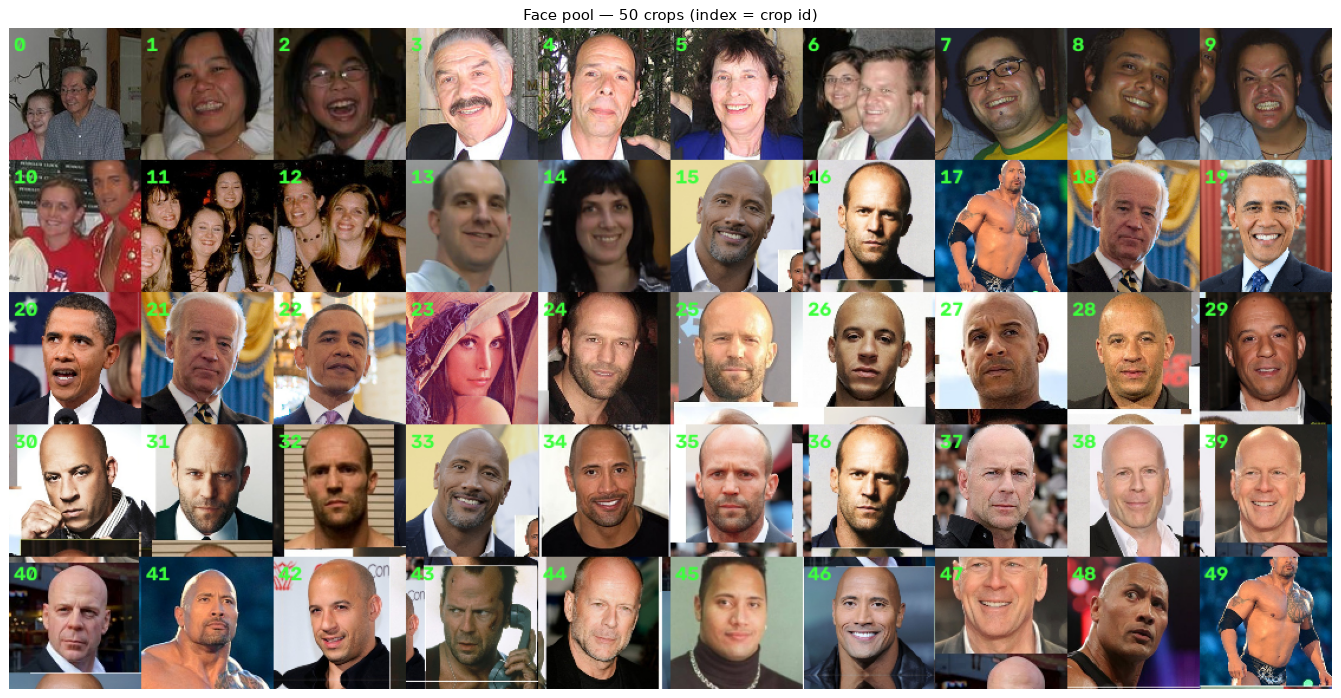

In [4]:
# show the whole face pool
thumbs = []
for i, f in enumerate(face_files):
    t = cv2.resize(cv2.imread(str(f)), (112, 112))
    cv2.putText(t, str(i), (4, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (60, 255, 60), 2)
    thumbs.append(cv2.cvtColor(t, cv2.COLOR_BGR2RGB))
cols = 10
rows = [np.hstack(thumbs[i:i+cols] + [np.full((112,112,3),255,np.uint8)]*(cols-len(thumbs[i:i+cols])))
        for i in range(0, len(thumbs), cols)]
plt.figure(figsize=(15, 1.7*len(rows)))
plt.imshow(np.vstack(rows)); plt.axis('off')
plt.title(f'Face pool — {len(face_files)} crops (index = crop id)')
plt.tight_layout(); plt.show()

## 3 · Facial landmarks (alignment strategy)
The **MediaPipe Face Landmarker** predicts a dense mesh of **478 landmarks** covering the jawline,
eyebrows, eyes, iris, nose and lips. Because both faces are annotated by the *same* topology,
landmark *i* on face A always corresponds semantically to landmark *i* on face B — this dense
point-to-point correspondence **is** the alignment: no manual point clicking and no rigid
pre-registration is needed. We append the 4 image corners and 4 edge mid-points so the
triangulation covers the full frame (hair/background morph too, instead of leaving holes).

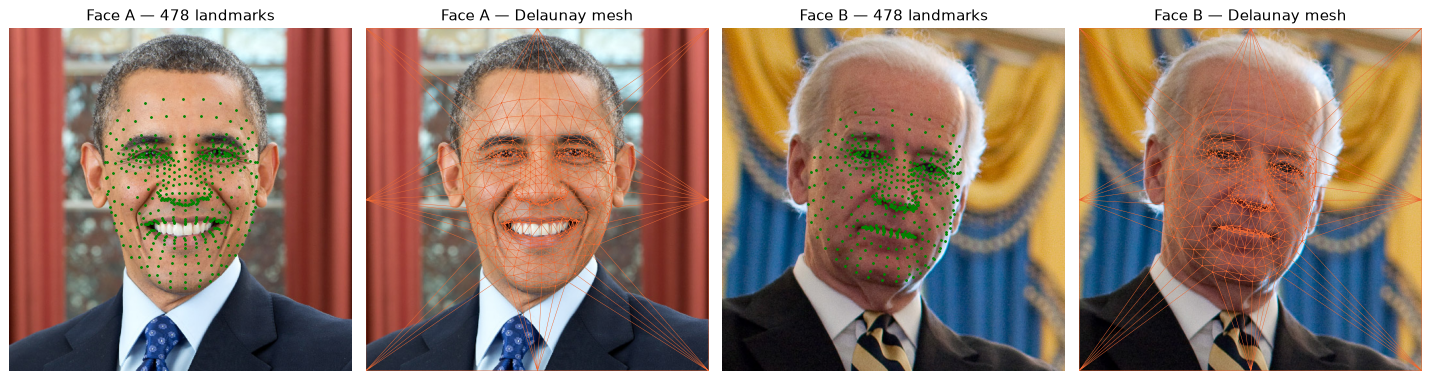

landmarks per face: 478 (+8 boundary points for triangulation)


In [5]:
def get_landmarks(img_bgr):
    res = landmarker.detect(to_mp(img_bgr))
    if not res.face_landmarks:
        return None
    h, w = img_bgr.shape[:2]
    pts = np.array([[lm.x * w, lm.y * h] for lm in res.face_landmarks[0]], dtype=np.float64)
    return np.clip(pts, 0, [w - 1, h - 1])

def with_boundary(pts, w, h):
    corners = np.array([[0,0],[w-1,0],[0,h-1],[w-1,h-1],
                        [w//2,0],[w//2,h-1],[0,h//2],[w-1,h//2]], dtype=np.float64)
    return np.vstack([pts, corners])

# visualize landmarks + triangulation on two sample faces
sampleA, sampleB = cv2.imread(str(face_files[19])), cv2.imread(str(face_files[18]))
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, img, title in [(axes[0], sampleA, 'Face A — 478 landmarks'), (axes[2], sampleB, 'Face B — 478 landmarks')]:
    pts = get_landmarks(img)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.scatter(pts[:,0], pts[:,1], s=1.5, c=C_GREEN)
    ax.set_title(title); ax.axis('off')
for ax, img, title in [(axes[1], sampleA, 'Face A — Delaunay mesh'), (axes[3], sampleB, 'Face B — Delaunay mesh')]:
    h, w = img.shape[:2]
    pts = with_boundary(get_landmarks(img), w, h)
    tri = Delaunay(pts)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.triplot(pts[:,0], pts[:,1], tri.simplices, lw=0.35, color=C_ORANGE)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print('landmarks per face:', len(get_landmarks(sampleA)), '(+8 boundary points for triangulation)')

## 4 · Morphing algorithm
For source faces $A$ and $B$ with corresponding landmark sets $P^A, P^B$ and blend factor
$\alpha \in [0,1]$:

1. **Shape interpolation** — the target (morphed) geometry is the linear interpolation of the shapes:
   $P^M_i = (1-\alpha)\,P^A_i + \alpha\,P^B_i$
2. **Delaunay triangulation** is computed **once on the interpolated shape** $P^M$ (computing it on
   the mid-shape avoids triangle flips that occur when a triangulation from one face is transplanted
   onto very different geometry).
3. **Piece-wise affine warp** — for every triangle $t$, the affine map from $t$'s vertices in $A$
   (resp. $B$) to its vertices in $M$ is estimated with `cv2.getAffineTransform` and applied with
   `cv2.warpAffine`; masking assembles the full warped images $W_A, W_B$ triangle by triangle.
4. **Colour interpolation (cross-dissolve)** — the aligned images are blended pixel-wise:
   $M = (1-\alpha)\,W_A + \alpha\,W_B$

With $\alpha=0.5$ the morph inherits half of each identity — the classical *morphing-attack*
setting where one passport photo should match two people.

In [6]:
def warp_triangle(src, dst, t_src, t_dst):
    r1, r2 = cv2.boundingRect(np.float32([t_src])), cv2.boundingRect(np.float32([t_dst]))
    if r2[2] == 0 or r2[3] == 0:
        return
    t1 = [(t_src[i][0]-r1[0], t_src[i][1]-r1[1]) for i in range(3)]
    t2 = [(t_dst[i][0]-r2[0], t_dst[i][1]-r2[1]) for i in range(3)]
    patch = src[r1[1]:r1[1]+r1[3], r1[0]:r1[0]+r1[2]]
    if patch.size == 0:
        return
    M = cv2.getAffineTransform(np.float32(t1), np.float32(t2))
    warped = cv2.warpAffine(patch, M, (r2[2], r2[3]), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REFLECT_101)
    mask = np.zeros((r2[3], r2[2], 3), dtype=np.float32)
    cv2.fillConvexPoly(mask, np.int32(t2), (1.0, 1.0, 1.0), 16, 0)
    roi = dst[r2[1]:r2[1]+r2[3], r2[0]:r2[0]+r2[2]]
    roi[:] = roi * (1 - mask) + warped.astype(np.float32) * mask

def warp_to_shape(img, pts_src, pts_dst, simplices):
    out = np.zeros_like(img, dtype=np.float32)
    for tri_idx in simplices:
        warp_triangle(img, out, pts_src[tri_idx].astype(np.float32),
                      pts_dst[tri_idx].astype(np.float32))
    return out

def morph_faces(imgA, imgB, alpha=0.5, return_aligned=False):
    h, w = imgA.shape[:2]
    ptsA = with_boundary(get_landmarks(imgA), w, h)
    ptsB = with_boundary(get_landmarks(imgB), w, h)
    ptsM = (1 - alpha) * ptsA + alpha * ptsB               # shape interpolation
    simplices = Delaunay(ptsM).simplices                   # triangulate mid-way shape
    warpA = warp_to_shape(imgA, ptsA, ptsM, simplices)     # piece-wise affine warps
    warpB = warp_to_shape(imgB, ptsB, ptsM, simplices)
    morph = (1 - alpha) * warpA + alpha * warpB            # cross-dissolve
    morph = np.clip(morph, 0, 255).astype(np.uint8)
    if return_aligned:
        return morph, warpA.astype(np.uint8), warpB.astype(np.uint8)
    return morph

# quick smoke test
_m = morph_faces(sampleA, sampleB, 0.5)
print('morph output:', _m.shape, _m.dtype)

morph output: (512, 512, 3) uint8


## 5 · Deliverable 1 — five (+) pairs of originals and their morphs
Each row shows *subject A*, the *50 / 50 morph*, and *subject B*. The images are also written to
`results/morph_pairs/`.

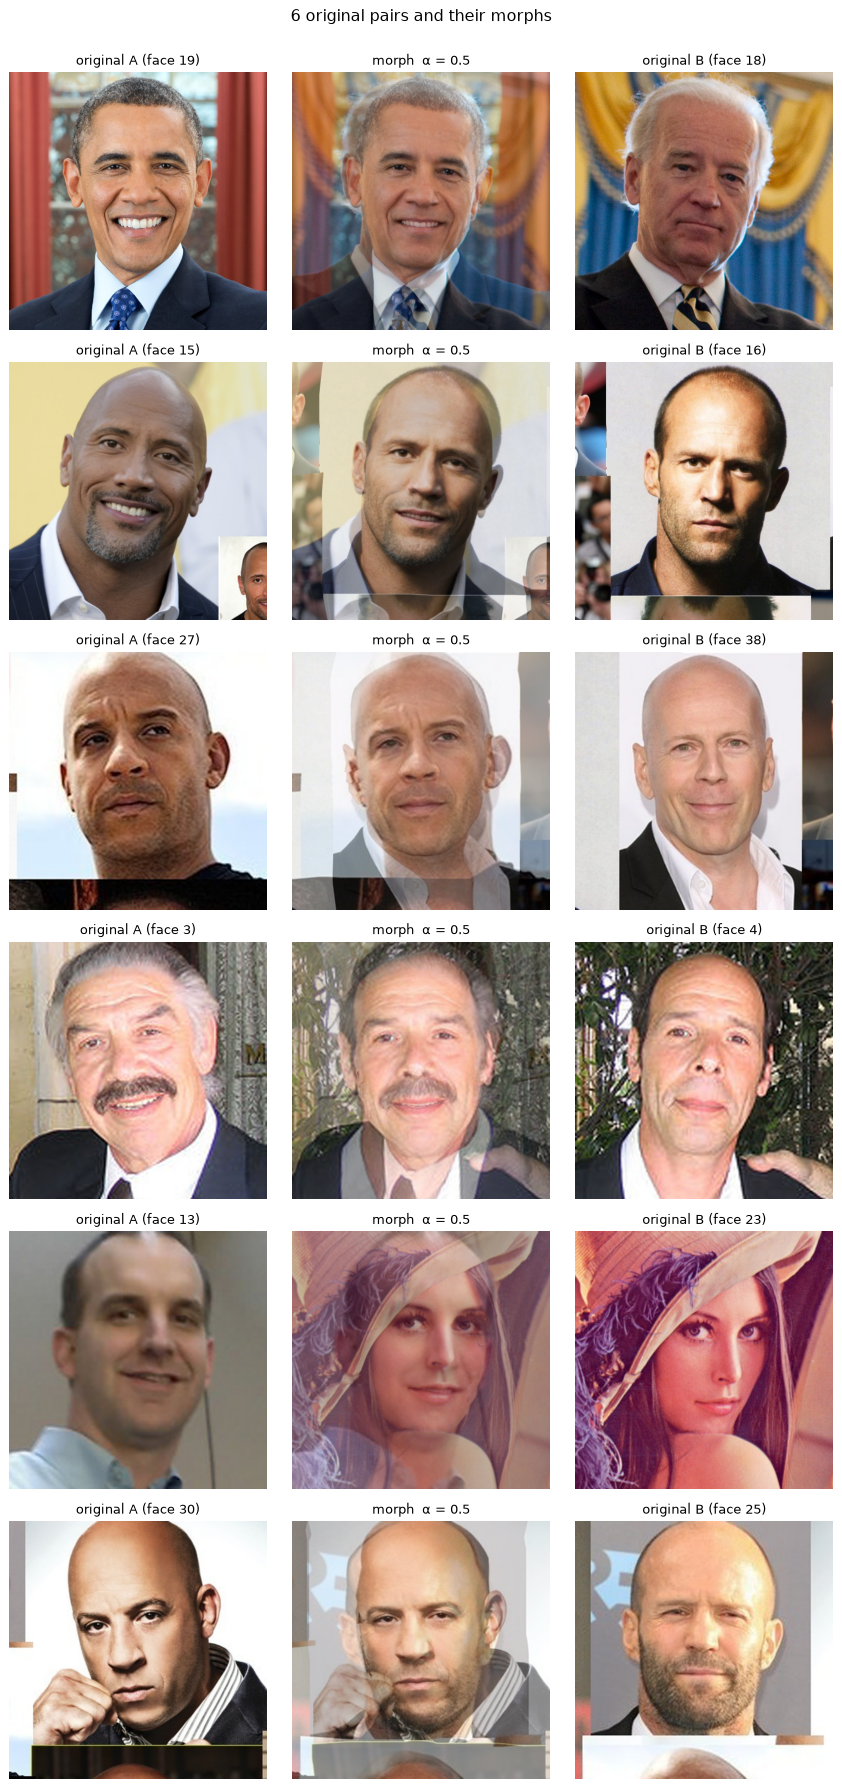

saved to /home/user/morhping-detection/results/morph_pairs


In [7]:
SHOWCASE = [(19, 18), (15, 16), (27, 38), (3, 4), (13, 23), (30, 25)]  # (A, B) crop ids

fig, axes = plt.subplots(len(SHOWCASE), 3, figsize=(9.6, 3.3 * len(SHOWCASE)))
for r, (ia, ib) in enumerate(SHOWCASE):
    A, B = cv2.imread(str(face_files[ia])), cv2.imread(str(face_files[ib]))
    M = morph_faces(A, B, 0.5)
    cv2.imwrite(str(PAIRS_OUT/f'pair{r+1}_A_face{ia:03d}.png'), A)
    cv2.imwrite(str(PAIRS_OUT/f'pair{r+1}_B_face{ib:03d}.png'), B)
    cv2.imwrite(str(PAIRS_OUT/f'pair{r+1}_morph.png'), M)
    for c, (img, ttl) in enumerate([(A, f'original A (face {ia})'),
                                    (M, 'morph  α = 0.5'),
                                    (B, f'original B (face {ib})')]):
        axes[r, c].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(ttl, fontsize=10); axes[r, c].axis('off')
plt.suptitle(f'{len(SHOWCASE)} original pairs and their morphs', y=1.001, fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS/'part1_showcase_pairs.png', bbox_inches='tight'); plt.show()
print('saved to', PAIRS_OUT)

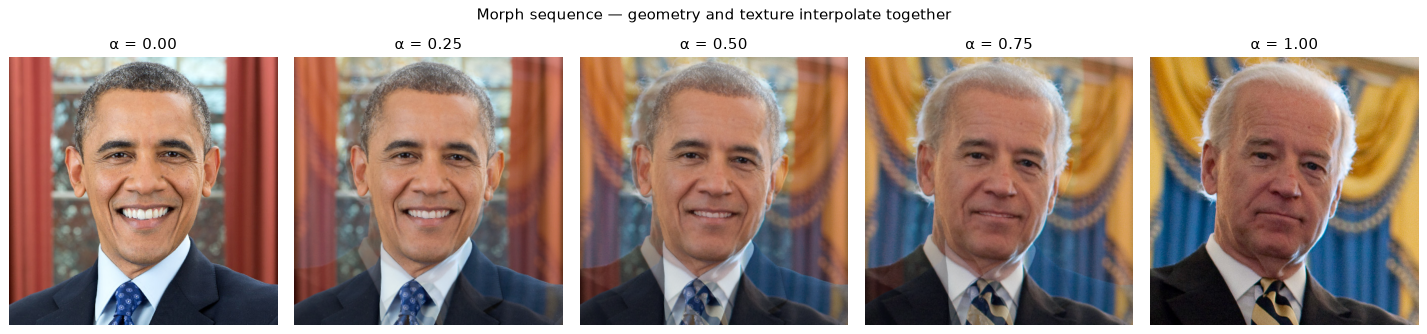

In [8]:
# full morph sequence for one pair — how identity shifts with alpha
A, B = cv2.imread(str(face_files[19])), cv2.imread(str(face_files[18]))
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(alphas), figsize=(16, 3.6))
for ax, a in zip(axes, alphas):
    img = A if a == 0 else B if a == 1 else morph_faces(A, B, a)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'α = {a:.2f}'); ax.axis('off')
plt.suptitle('Morph sequence — geometry and texture interpolate together', y=1.02)
plt.tight_layout(); plt.savefig(RESULTS/'part1_morph_sequence.png', bbox_inches='tight'); plt.show()

## 6 · Deliverable 2 — labelled dataset for Part 2 (detection)
We now produce the dataset the detector is trained on:

* **Identity-disjoint split** — crops are grouped by their *source photograph* (all crops that come
  from the same photo share background, lighting and possibly identity). Whole groups go either to
  *train* or *test*, so no identity/scene ever appears on both sides (the paper stresses the same
  protocol: *"the model doesn't see the same identities in both training and testing"*).
* **Morph generation** — random pairs *within the same split* are morphed with a random
  α ∈ {0.3 … 0.7} (α = 0.5 ± spread, as used for realistic morphing attacks).
* Layout: `data/dataset/{train|test}/{real|morph}/*.png` + `manifest.csv`.

In [9]:
GROUP_RE = re.compile(r'face_\d+_(.+?)(?:_t\d+x\d+)?$')
def group_of(path):
    return GROUP_RE.match(Path(path).stem).group(1)

TEST_GROUPS = {'fr_obama', 'fr_obama2', 'fr_biden', 'fr_two_people', 'opencv_lena',
               'dlib_2008_004176', 'dlib_2008_007676', 'dlib_2009_004587'}

split_of = {f: ('test' if group_of(f) in TEST_GROUPS else 'train') for f in face_files}
train_faces = [f for f in face_files if split_of[f] == 'train']
test_faces  = [f for f in face_files if split_of[f] == 'test']
print(f'real crops   train: {len(train_faces)}   test: {len(test_faces)}')
print('train groups:', sorted({group_of(f) for f in train_faces}))
print('test  groups:', sorted({group_of(f) for f in test_faces}))

N_TRAIN_MORPHS, N_TEST_MORPHS = 130, 40

def sample_pairs(files, n, rng):
    all_pairs = [(a, b) for i, a in enumerate(files) for b in files[i+1:]]
    rng.shuffle(all_pairs)
    return all_pairs[:n]

manifest = []
rng = random.Random(SEED)
for split, faces_, n_morphs in [('train', train_faces, N_TRAIN_MORPHS),
                                ('test',  test_faces,  N_TEST_MORPHS)]:
    for cls in ('real', 'morph'):
        (DATASET/split/cls).mkdir(parents=True, exist_ok=True)
    for f in faces_:                                   # copy real crops
        dst = DATASET/split/'real'/f.name
        if not dst.exists():
            shutil.copy(f, dst)
        manifest.append((f'{split}/real/{f.name}', 'real', split, group_of(f), '', ''))
    pairs = sample_pairs(faces_, n_morphs, rng)
    for k, (fa, fb) in enumerate(pairs):               # generate morphs
        alpha = rng.choice([0.3, 0.4, 0.5, 0.6, 0.7])
        name = f'morph_{split}_{k:03d}.png'
        dst = DATASET/split/'morph'/name
        if not dst.exists():
            M = morph_faces(cv2.imread(str(fa)), cv2.imread(str(fb)), alpha)
            cv2.imwrite(str(dst), M)
        manifest.append((f'{split}/morph/{name}', 'morph', split,
                         f'{group_of(fa)}+{group_of(fb)}', fa.name, f'{alpha}'))

with open(DATASET/'manifest.csv', 'w') as fh:
    fh.write('path,label,split,group,parentA,alpha\n')
    for row in manifest:
        fh.write(','.join(row) + '\n')

counts = {(s, c): sum(1 for m in manifest if m[2] == s and m[1] == c)
          for s in ('train', 'test') for c in ('real', 'morph')}
print('dataset written to', DATASET)
print(counts)

real crops   train: 39   test: 11
train groups: ['dlib_2007_007763', 'dlib_2008_001009', 'dlib_2008_001322', 'dlib_2008_002079', 'dlib_2008_002506', 'dlib_bald_guys']
test  groups: ['dlib_2008_004176', 'dlib_2008_007676', 'dlib_2009_004587', 'fr_biden', 'fr_obama', 'fr_obama2', 'fr_two_people', 'opencv_lena']


dataset written to /home/user/morhping-detection/data/dataset
{('train', 'real'): 39, ('train', 'morph'): 130, ('test', 'real'): 11, ('test', 'morph'): 40}


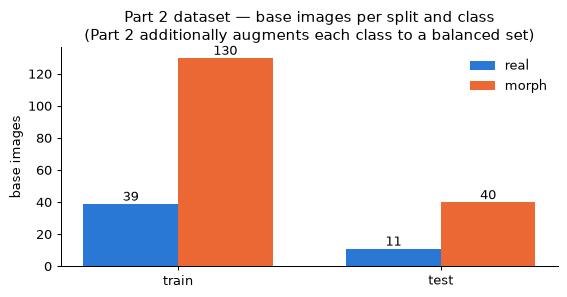

In [10]:
# class balance overview
fig, ax = plt.subplots(figsize=(6.4, 3.4))
splits = ['train', 'test']
x = np.arange(len(splits)); wdt = 0.36
real_c  = [counts[(s, 'real')]  for s in splits]
morph_c = [counts[(s, 'morph')] for s in splits]
b1 = ax.bar(x - wdt/2, real_c,  wdt, color=C_BLUE,   label='real')
b2 = ax.bar(x + wdt/2, morph_c, wdt, color=C_ORANGE, label='morph')
ax.bar_label(b1); ax.bar_label(b2)
ax.set_xticks(x, splits); ax.set_ylabel('base images')
ax.set_title('Part 2 dataset — base images per split and class\n(Part 2 additionally augments each class to a balanced set)')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part1_dataset_counts.png', bbox_inches='tight'); plt.show()

## 7 · Short report — Part 1

### Method used
A classical **landmark-based morphing pipeline** (OpenCV + MediaPipe, no external morphing
software): face detection (BlazeFace) → 512×512 face crops → 478-point face mesh
(MediaPipe Face Landmarker) → linear **shape interpolation** of corresponding landmarks →
**Delaunay triangulation** of the interpolated shape → **piece-wise affine warping** of both
originals onto that shape → **cross-dissolve** of the aligned images. Six showcase pairs and
170 dataset morphs were produced fully automatically.

### Landmark alignment strategy
Alignment relies on the *fixed topology* of the MediaPipe mesh: landmark *i* refers to the same
anatomical point on every face, giving a dense 478-point correspondence without manual annotation.
Eight frame boundary points (corners + edge midpoints) are appended so the triangulation tiles the
whole image and the background/hair regions are warped consistently. The triangulation is computed
**on the interpolated (mid-way) shape** — using one face's triangulation on very different geometry
can produce flipped/degenerate triangles.

### Interpolation technique
Two independent linear interpolations controlled by the same α:
**geometry** `P_M = (1−α)·P_A + α·P_B` (per-landmark), then per-triangle affine warps bring both
images onto `P_M`; **appearance** `M = (1−α)·W_A + α·W_B` (per-pixel cross-dissolve of the two
*geometry-aligned* images). For the dataset, α is drawn from {0.3, 0.4, 0.5, 0.6, 0.7}; showcase
morphs use α = 0.5.

### Observations and limitations
* Morphs of frontal, similarly-lit faces are highly convincing; the identity mixture is clearly
  visible at α = 0.5 and drifts smoothly across the sequence.
* Typical **artifacts**: ghosting around hairlines, ears, glasses and clothing edges (these regions
  have no landmarks, so only the sparse boundary points constrain them); double contours when head
  pose differs strongly; slight blur added by bilinear resampling + averaging — precisely the
  high-frequency cues Part 2's detector exploits.
* **Limitations**: single 2-D triangulated mesh (no occlusion/3-D handling), no color rebalancing
  between donors, no Poisson/seamless blending or GAN-based post-processing, and the face pool is
  small and celebrity-biased. Landmark quality degrades on strongly non-frontal faces, which limits
  usable source pairs.